Osnabrück University - Computer Vision (Winter Term 2024/25) - Dr. Ulf Krumnack, Lukas Niehaus, Robin Rawiel

# Exercise Sheet 01: Image Enhancement & Color

## Introduction

This is the first "real" homework sheet.

The homework sheets will usually be available at the beginning of the week and are supposed to be solved in groups. They have to be handed in before the next practice session (Monday evening). The exercises are then presented to your tutor in a small feedback session. To acquire the admission for the final exam, you will have to pass 𝑁−2 of the weekly provided exercise sheets.

Sign up for a group on Stud.IP if you have not already done so (See Participants -> Functions/Groups). The times mentioned there are the times for the feedback session of your group. If none of them fits, send any of the tutors an e-mail so we can try to arrange something.

Your group will have a group folder in Stud.IP under Documents. Upload your solutions there to hand them in.

This week's sheet should be solved and handed in before end of **Monday, November 17, 2024**. Please upload your results to your group's Stud.IP folder.

## Assignment 1: Computing Contrast and Entropy (5 points)


### a) Computing contrast

Provide functions to compute the local contrast, global contrast, and entropy of an image.

1.0


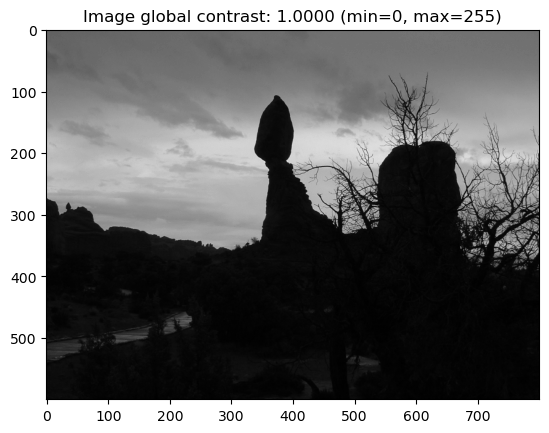

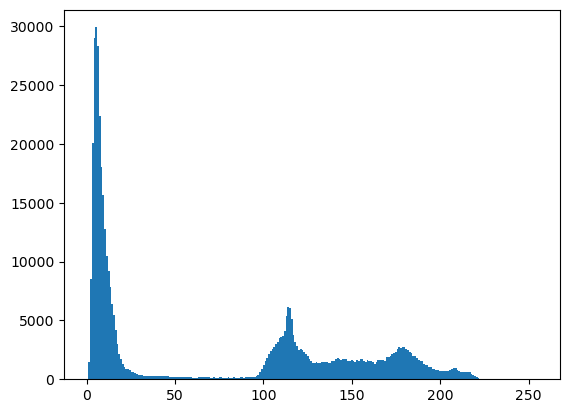

In [2]:
%matplotlib inline
import numpy as np
from imageio.v2 import imread
import matplotlib.pyplot as plt
plt.rcParams['image.cmap'] = 'gray'

def global_contrast(img, value_range=None):
    """
    Compute the global contrast for a given image.
    Args:
        img (ndarray): The grayscale image to compute the contrast for.
        value_range (tuple): The minimum and maximum values of the gray scale.
    
    Returns:
        contrast (float): The global contrast of the image. 
    """

    # determine range: simplified, just checks for uint8 
    if value_range is None:
        value_range = (0, 255) if img.dtype == np.uint8 else (0., 1.)

    max_image = img.max()
    min_image = img.min()
    
    
    # YOUR CODE HERE
    # raise NotImplementedError()
    contrast = (1/ (value_range[1] - value_range[0])) * (max_image - min_image)
    print(contrast)
    return contrast

img = imread('images/dark.png')
plt.title("Image global contrast: {:.4f} (min={}, max={})".format(global_contrast(img), img.min(), img.max()))
plt.imshow(img, vmin=0, vmax=255)
plt.show()

plt.hist(img.flatten(), 256, (0, 255))
plt.show()

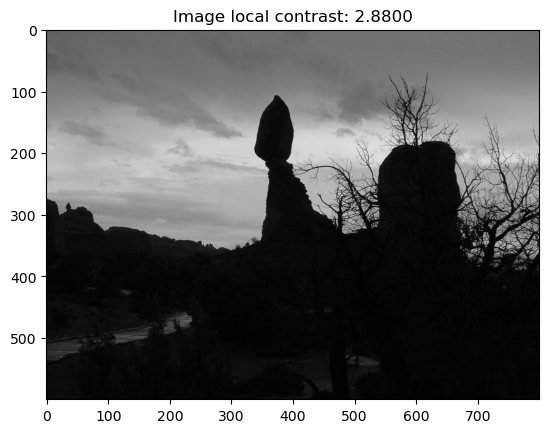

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from imageio.v2 import imread

def local_contrast(img):
    """
    Compute the local contrast for a given image.
    Args:
        img (ndarray): The grayscale image to compute the contrast for.
    
    Returns:
        contrast (float): The local contrast of the image. 
    """
    
    # YOUR CODE HERE
   # raise NotImplementedError()
    img = img.astype(np.float32) #convert to float bacause of the overflow problem

    M, N = img.shape
    total_contrast = 0
    count = 0
    
    for i in range(1, M-1):
        for j in range(1, N-1):
            pixel_image = img[i, j]
            
            k_mean = (img[i+1, j] + img[i-1, j] + img[i, j-1] + img[i, j+1]) / 4
            
            total_contrast += abs(pixel_image - k_mean)
            count += 1
    contrast = total_contrast / count
    return contrast

    

img = imread('images/dark.png')
plt.title("Image local contrast: {:.4f}".format(local_contrast(img)))
plt.imshow(img, vmin=0, vmax=255)
plt.show()

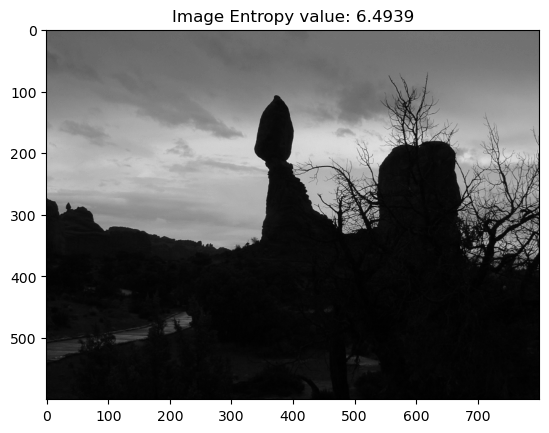

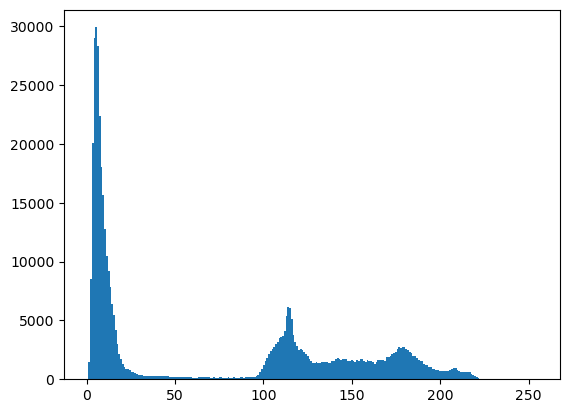

In [4]:
%matplotlib inline
import numpy as np
import math
from imageio.v2 import imread
import scipy.stats 

#  scipy.stats.entropy  https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.entropy.html

def entropy(img):
    """
    Compute the entropy for a given image.
    Args:
        img (ndarray): The grayscale image to compute the entropy for.
    
    Returns:
        img_entropy (float): The entropy of the image. 
    """
    # YOUR CODE HERE
    #raise NotImplementedError()
    oned_array = img.flatten()
    hist, bin_edges = np.histogram(oned_array, bins=256, range=(0, 256))
    
    #--------------Solution 1-------------------*
    image_entropy = scipy.stats.entropy(hist, base=2)
    
    #--------------Solution 2-------------------*
    #normalized_hist = hist / hist.sum() 
    #E_array = -normalized_hist[normalized_hist > 0] * np.log2(normalized_hist[normalized_hist > 0])
    #image_entropy = np.sum(E_array)
    
    return image_entropy


img = imread('images/dark.png')
plt.title("Image Entropy value: {:.4f}".format(entropy(img)))
plt.imshow(img, vmin=0, vmax=255)
plt.show()

plt.hist(img.flatten(), 256, (0, 255))
plt.show()

assert math.isclose(entropy(img), scipy.stats.entropy(np.unique(img.flat, return_counts=True)[1], base=2))

### b) Example images

* construct an (artificial) image with high global contrast but low local contrast
* construct an (artificial) image with low global constrast but high local contrast
* construct an (artificial) image with maximal entropy but low local contrast

Image1: We create a completely black image with only one white pixel, providing high global contrast with low local contrast.

Image 2: a checkerboard pattern is created by alternating black (0) and white (255) squares every two pixels. This results in low global contrast but high local contrast, as brightness changes quickly within small regions.

Image 3: we use np.linspace to create a smooth horizontal gradient from black (0) to white (255) across the entire image. This image has high entropy but low local contrast.

1.0


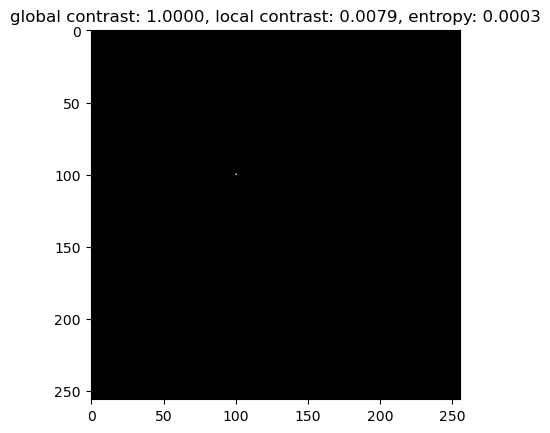

0.39215686274509803


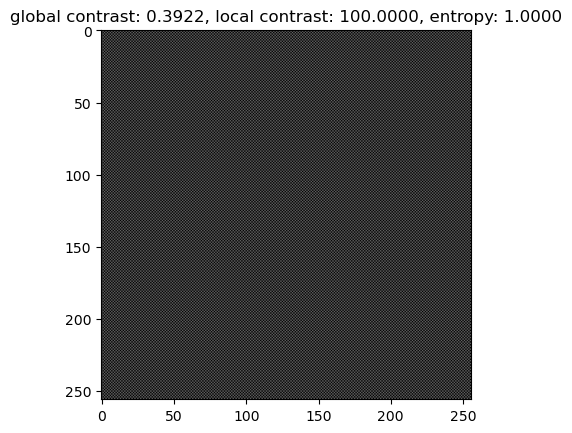

1.0


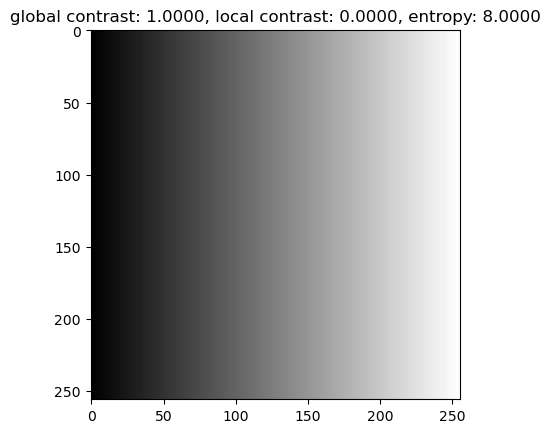

In [5]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

def image_info(img):
    """ Displays an image, local and global contrast, and the entropy
    
    Args:
        img (ndarray): Image which is displayed and statics are computed for.
        
    """
    info = "global contrast: {:.4f}, local contrast: {:.4f}, entropy: {:.4f}"
    plt.title(info.format(global_contrast(img), local_contrast(img), entropy(img)))
    plt.imshow(img, vmin=0, vmax=255)
    plt.show()


#gradient
img1 = np.zeros((256, 256),np.uint8)
img1[100,100] = 255
image_info(img1)


#checkerboard
img2 = np.zeros((256, 256),np.uint8)
for j in range(img2.shape[0]):
    for i in range(img2.shape[1]):
        if (i+j)%2 == 0:
            img2[i,j] = 100
            
image_info(img2)


# image3: maximal entropy but low local contrast(random noise)
img3 = np.zeros((256, 256),np.uint8)
# YOUR CODE HERE
# raise NotImplementedError()
img3 = np.tile(np.linspace(0, 255, 256, dtype=np.uint8), (256, 1))  #gradient from 0 to 255
image_info(img3)

## Assignment 2: Contrast enhancement (5 points)

### a) Image Contrast

Describe the concept of contrast in your own words and introduce different ways to measure it. How can low contrast be caused and when is this a problem (and when not)? What can be done to improve contrast?

YOUR ANSWER HERE

Contrast in an image is essentially the difference in brightness or gray values that allows distinct features to stand out. It includes global contrast, which is the difference between the darkest and brightest areas of the entire image, and local contrast, which measures brightness differences within smaller regions or between neighboring pixels. Low contrast can stem from poor lighting during image capture, foggy or hazy environments, or overexposure and underexposure, which may result in a limited range of gray values. While low contrast can obscure details critical for precise tasks, such as medical imaging or object detection, it may not be problematic when only broad outlines are required.

To improve contrast, several methods are commonly applied. Linear transformations adjust the brightness range across the image, while gamma correction allows non-linear adjustments that can highlight details in specific regions. Histogram equalization enhances contrast by redistributing pixel values to make fuller use of the available gray levels, which maximizes information content or entropy. Adaptive Histogram Equalization (AHE) further extends this approach by enhancing contrast within local regions of the image, making it suitable for images with uneven lighting. Contrast-Limited Adaptive Histogram Equalization (CLAHE) refines AHE by limiting contrast enhancement to avoid amplifying noise. These techniques collectively serve to enhance detail and visibility in images with naturally low contrast, improving their quality for human and machine analysis.

### b) Histogram equalization and entropy

How does histogram equalization work? What is entropy and how is it related to histogram equalization? For your answer focus on the (conceptually simpler) continuous case.

YOUR ANSWER HERE

Histogram equalization is a technique used to enhance the contrast of an image by redistributing the pixel intensities so that they span the full available range more evenly.conceptually, it works by transforming the histogram of an image’s pixel values into a uniform distribution. in a continuous case, this involves mapping the cumulative distribution function (CDF) of the image's intensity values onto a range where each possible intensity level is represented more equally.this approach enhances areas of the image that may initially have a narrow range of brightness levels, thus increasing visual clarity.

entropy, in the context of images, represents the amount of information or uncertainty in the pixel values.It is calculated as the average information content, or the sum of probabilities of each intensity level times the log of that probability, across all intensities. Histogram equalization and entropy are closely related because a histogram with maximum entropy represents an image with a uniform distribution of intensity values, which means each intensity is equally likely. When histogram equalization is applied, it tends to increase the entropy of the image by equalizing the distribution of intensity levels, thereby maximizing the information content and making the image clearer for both human perception and automated analysis.

### c) Discrete histogram equalization

What problems occur when considering discrete images (i.e. with discrete coordinates and a finite number of gray levels)? Explain the tables on the lecture slides (CV-02 slides 29-32).

YOUR ANSWER HERE

In discrete images, histogram equalization faces challenges due to the limited number of gray levels and pixel coordinates. Unlike in continuous cases, discrete images can only adjust pixel intensities within specific gray-level bins, often causing quantization artifacts where certain intensity levels appear as abrupt steps or gaps. This can distort visual quality, particularly in areas with small, specific intensity ranges, as equalization struggles to distribute intensities smoothly across the image.

???????????????The slides (29-32) illustrate these challenges in discrete histogram equalization. Slide 29 introduces the concept for discrete images, explaining the goal of redistributing intensities more evenly. Slide 30 shows how limited gray levels complicate achieving a uniform distribution, often resulting in clusters of pixels with identical adjusted intensities. Slides 31 and 32 demonstrate examples where certain intensity levels are either over-represented or under-represented after equalization, which leads to bands or patches of similar intensities rather than smooth transitions. This effect is especially noticeable in images with large uniform areas or subtle gradients, where discrete equalization may not achieve the desired visual enhancement.

Explanation of the Tables
Gray Value: The gray value range consists of different possible values. In a 3-bit system, therefore, the number of discrete gray values is 2^3=8.

Frequency: In this context, the frequency of each category corresponds to the number of pixels that share the same gray value as the category’s value.

H(g): The normalized histogram is calculated by dividing the frequency of each gray value by the total number of considered pixels (in this case, 1000). This provides a probability distribution of the intensity values.

Accumulated: This value represents the sum of the category value and the values of all lower categories. Essentially, it is a cumulative count up to that point.

Gray Value Calculation: The gray value is computed as the accumulated value multiplied by the maximum gray value (which is 8 in this example). The result is then rounded up to the nearest larger integer and reduced by 1.

H(g'): This aspect describes the new frequency distribution based on the new scale introduced in the transformation. For example, H(g'(7)= 0.10 + 0.06 + 0.03 + 0.01 = 0.20.
This cumulative probability reflects changes in the mapping of the intensity values after applying the transformation.

But it can lead to non equalized histogram in discrited images as showm in the slide 32:
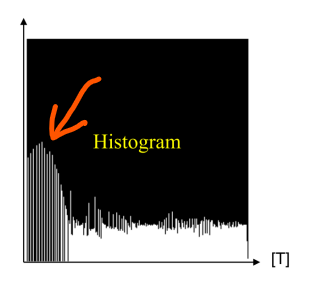

## Assignment 3: Adaptive Histogram Equalization (5 points)

We have uploaded the original article on Contrast Limited Adaptive Histogram Equalization to StudIP [Zuiderveld, 1994](Zuiderveld-1994.pdf). You may use it as a base to answer this exercise.

### a) Adaptive Histogram Equalization (AHE)

Describe in your own words the idea of AHE. Why was it introduced and what are its main drawbacks?

YOUR ANSWER HERE

Adaptive Histogram Equalization (AHE) is a method developed to enhance image contrast by equalizing histogram values within local regions of the image rather than globally. The goal of AHE is to make details in darker or lighter areas more visible, especially in images with non-uniform lighting or contrast. Instead of applying histogram equalization over the entire image, AHE divides the image into smaller regions (tiles) and applies equalization to each one independently, adapting the contrast enhancement to local intensity variations.

AHE was introduced to address the limitations of global histogram equalization, which often fails in images where contrast varies across regions. Global methods can over-enhance bright or dark areas while leaving other areas poorly contrasted. By focusing on local regions, AHE allows for more balanced and context-sensitive contrast enhancement.

However, AHE has drawbacks. Its most significant issue is that it tends to amplify noise in relatively uniform areas, as it boosts local contrast even when there are no meaningful details. This can make random variations appear exaggerated, creating distracting artifacts. Additionally, AHE can produce unnatural-looking images when applied to areas with slight intensity variations. Contrast-Limited Adaptive Histogram Equalization (CLAHE) was later introduced as a solution to these issues by limiting the degree of local contrast enhancement in order to reduce noise amplification and maintain a more natural look.

### b) Contrast Limited Adaptive Histogram Equalization (CLAHE)

Describe in your own words the idea of CLAHE. Why was it introduced and how does it work? 

YOUR ANSWER HERE

Contrast Limited Adaptive Histogram Equalization (CLAHE) was developed as an extension of Adaptive Histogram Equalization (AHE) to address its limitations. While AHE enhances contrast in local image regions, it can lead to excessive noise amplification in uniform areas, as it enhances even minor, irrelevant intensity variations. CLAHE mitigates this by limiting the contrast enhancement in each local region to a predefined maximum. This "contrast limiting" prevents over-emphasis of noise and maintains image naturalness.

The CLAHE process divides an image into small tiles, similar to AHE, and calculates histograms for each. However, before applying equalization, it clips histogram peaks that exceed a set threshold, redistributing these excess pixels evenly across the histogram. This clipping reduces the impact of small, noisy variations. Finally, CLAHE combines the locally enhanced regions by smoothly blending their borders to avoid artifacts between adjacent tiles. By limiting local contrast, CLAHE effectively enhances details without over-amplifying noise, producing a balanced, clearer image.

### c) Computation of AHE

How can AHE be implemented efficiently? Explain how the interpolation scheme works, why it is a valid approximation, and why it improves the runtime? Can you think of another way to compute AHE efficiently?

YOUR ANSWER HERE

To implement Adaptive Histogram Equalization (AHE) efficiently, a practical approach uses an interpolation scheme that reduces computational costs. In AHE, the histogram needs to be computed for each pixel within its local neighborhood, which is computationally expensive. Instead, the image is divided into a grid of tiles, and histograms are calculated only for the center of each tile. To determine the pixel values between tile centers, AHE uses bilinear interpolation. Each pixel’s intensity adjustment is calculated by interpolating between the four nearest tile centers, reducing the need for individual histograms for each pixel.

This interpolation scheme is a valid approximation because the gradual blending between tile regions produces a smooth transition in intensity adjustments across the image, which is perceptually effective. It also significantly speeds up the runtime by eliminating redundant histogram computations and recalculations for every single pixel. Another efficient approach to computing AHE could involve using integral histograms, where a cumulative histogram is precomputed across the entire image. This allows rapid access to histograms for any given local region without recomputing from scratch.

### d) Applying AHE and CLAHE

Lookup functions for computing HE, AHE and CLAHE in the module `skimage.exposure` and apply them to the image `canada.png`. Compare your results to the lecture slides (CV-02, slide 24).

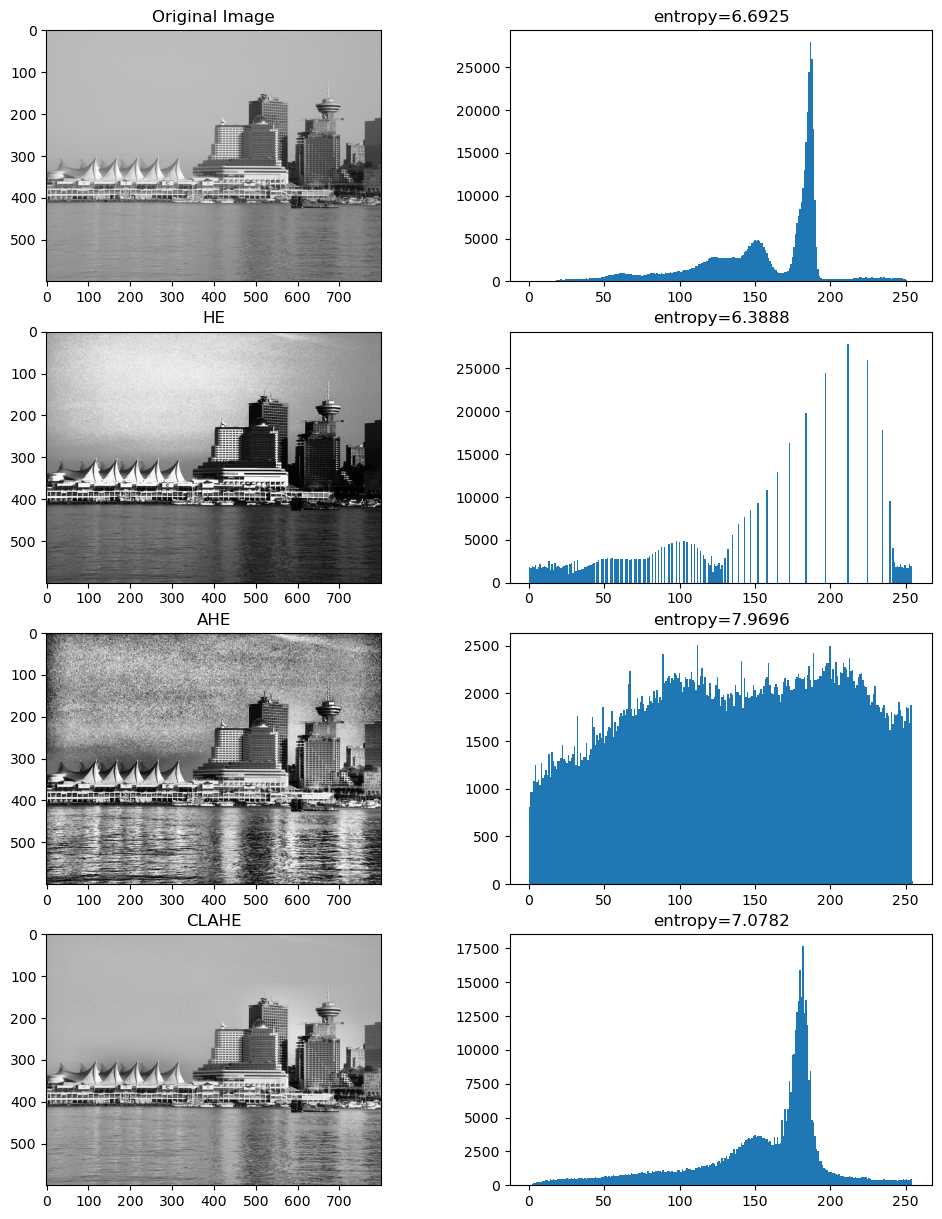

In [18]:
%matplotlib inline
# YOUR CODE HERE
# raise NotImplementedError()
from skimage import exposure

from imageio.v2 import imread
import matplotlib.pyplot as plt

img = imread('images/canada.png', pilmode='L')

img_he = (exposure.equalize_hist(img) * 255).astype('uint8')
img_ahe = (exposure.equalize_adapthist(img, clip_limit=1.0) * 255).astype('uint8')
img_clahe = (exposure.equalize_adapthist(img, clip_limit=0.01) * 255).astype('uint8')

#raise NotImplementedError()

plt.figure(figsize=(12, 15))
plt.subplot(4,2,1)
plt.title("Original Image")
plt.imshow(img)
plt.subplot(4,2,2)
plt.title("entropy={:.4f}".format(entropy(img)))
plt.hist(img.flatten(), 256, (0, 255))

plt.subplot(4,2,3)
plt.title("HE")
plt.imshow(img_he)
plt.subplot(4,2,4)
plt.title("entropy={:.4f}".format(entropy(img_he)))
plt.hist(img_he.flatten(), 256, (0, 255))

plt.subplot(4,2,5)
plt.title("AHE")
plt.imshow(img_ahe)
plt.subplot(4,2,6)
plt.title("entropy={:.4f}".format(entropy(img_ahe)))
plt.hist(img_ahe.flatten(), 256, (0, 255))

plt.subplot(4,2,7)
plt.title("CLAHE")
plt.imshow(img_clahe)
plt.subplot(4,2,8)
plt.title("entropy={:.4f}".format(entropy(img_clahe)))
plt.hist(img_clahe.flatten(), 256, (0, 255))

plt.show()

## Assignment 4: Colormaps (5 points)

Colormaps can be used to map a grayscale image to a pseudo color image for contrast enhancment for human viewing. Three non-monotonic functions are applied to map a gray value to each of the three color channels of the output image.


### a) Describe the following three colormap classes in one sentence each:

* Sequential
* Diverging
* Qualitative

You may have a look at the matplotlib documentation.

https://matplotlib.org/stable/index.html

Sequential: A colormap that gradually changes in lightness and color saturation, often used to represent data that goes from low to high values.

Diverging: A colormap with two contrasting colors that meet in the middle, used to highlight deviation from a central point or neutral value.

Qualitative: A colormap with distinct colors, used to represent categorical data without implying any order.

For each of the above colormap classes give one example and display the red, green, and blue curves like on (CV-02, slide 43):

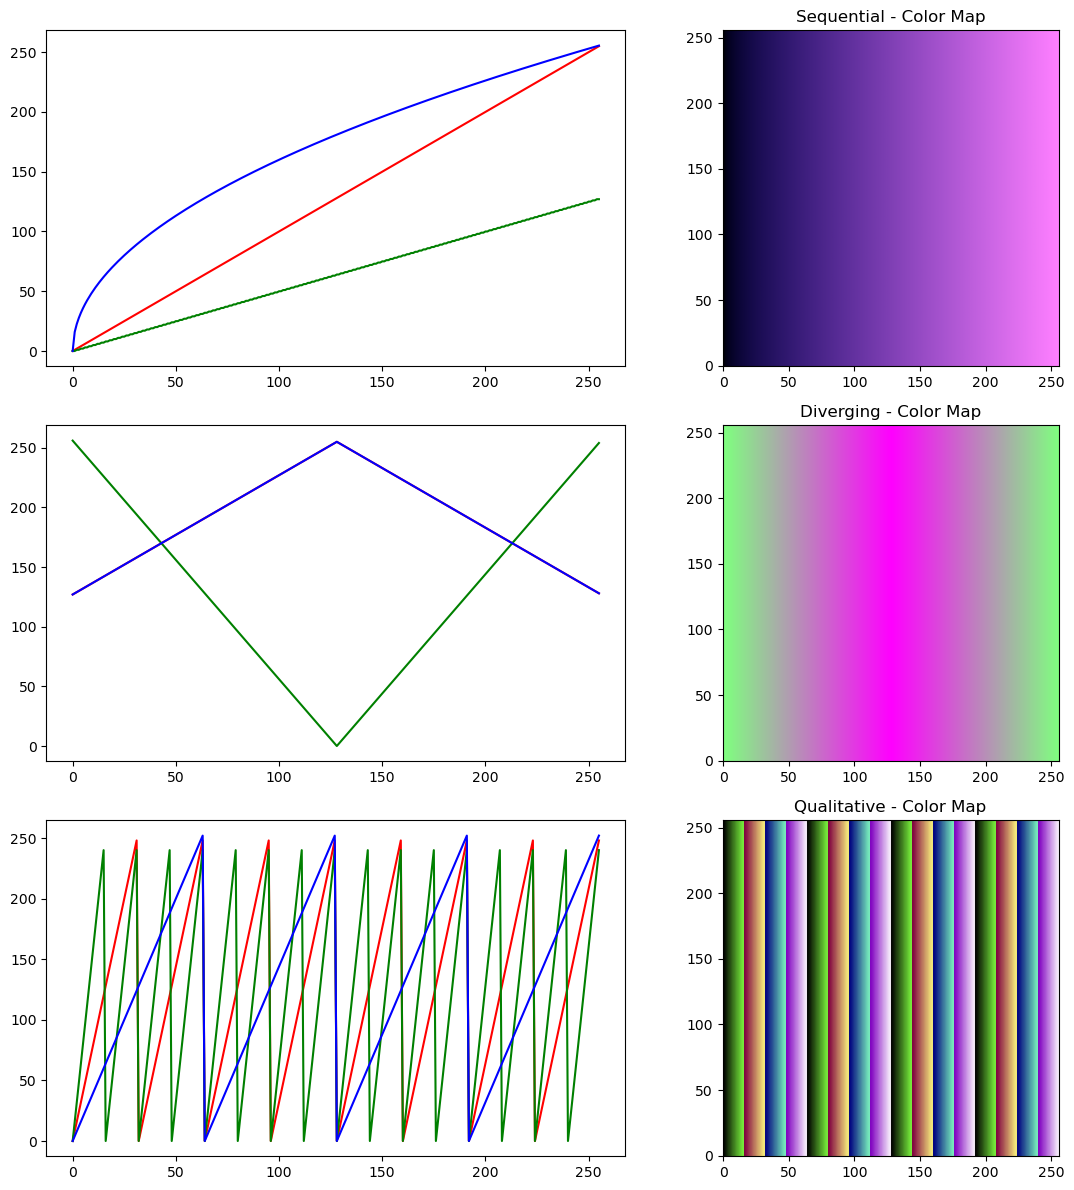

In [36]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import math

colors = []

# sequential-> smoothly increasing values for each color channel
colors.append((np.asarray((
    lambda x: x,                    
    lambda x: x // 2,              
    lambda x: np.sqrt(x) * 16       
)), "Sequential"))

# diverging->two contrasting colors meeting at the center
colors.append((np.asarray((
    lambda x: 255 - abs(x - 128),   
    lambda x: abs(x - 128) * 2,      
    lambda x: 255 - abs(x - 128)    
)), "Diverging"))

#qualitative->tep changes for categorical colors
colors.append((np.asarray((
    lambda x: (x % 32) * 8,         
    lambda x: (x % 16) * 16,        
    lambda x: (x % 64) * 4          
)), "Qualitative"))

gray = np.arange(0, 256)
a = np.tile(np.arange(256), (256, 1))

plt.figure(figsize=(12, 12))
for i, (color, label) in enumerate(colors):
    plt.subplot(len(colors), 2, i * 2 + 1)
    plt.plot(gray, color[0](gray), 'red')
    plt.plot(gray, color[1](gray), 'green')
    plt.plot(gray, color[2](gray), 'blue')
    #plt.legend()
  #  plt.title(f"{label} - RGB Curves")

    img_color = np.stack([color[0](a), color[1](a), color[2](a)], axis=2) / 255
    img_color = np.clip(img_color, 0, 1)  # [0, 1] range for `imshow`
    plt.subplot(len(colors), 2, i * 2 + 2)
    plt.imshow(img_color, origin='lower')
    plt.title(f"{label} - Color Map")

plt.tight_layout()
plt.show()

### b) Implement Cube Helix colormapping 
Generate a LookUp table with $256 \times 3$ entries describing the color values for all gray values beginning with black (0) up to white (255). Use the given parameters and use the following formula to compute an RGB value from a gray value $g$:
$$ \begin{pmatrix}R \\ G \\ B\end{pmatrix} =  
\begin{pmatrix} \lambda ^ \gamma \\ \lambda ^ \gamma \\ \lambda ^ \gamma \end{pmatrix} + a \begin{pmatrix}-0.14861 & + 1.78277 \\
-0.29227 & -0.90649 \\ +1.97294 & 0\end{pmatrix} \begin{pmatrix}\cos \phi \\ \sin \phi\end{pmatrix}$$
with $\phi = 2 \pi (\frac{\text{start\_color }}{3} + \text{rotations}\cdot \lambda)$ and $ a = \frac{\text{hue}\cdot \lambda ^ \gamma \cdot( 1 - \lambda ^ \gamma)}{2}$ (with 'start\_color', 'rotations' and 'hue' being parameters describing the form of the helix, and $\gamma$ being the usual $\gamma$-factor).

Remember that this formula is for values between $0$ and $1$.
For more information you may refer to http://astron-soc.in/bulletin/11June/289392011.pdf

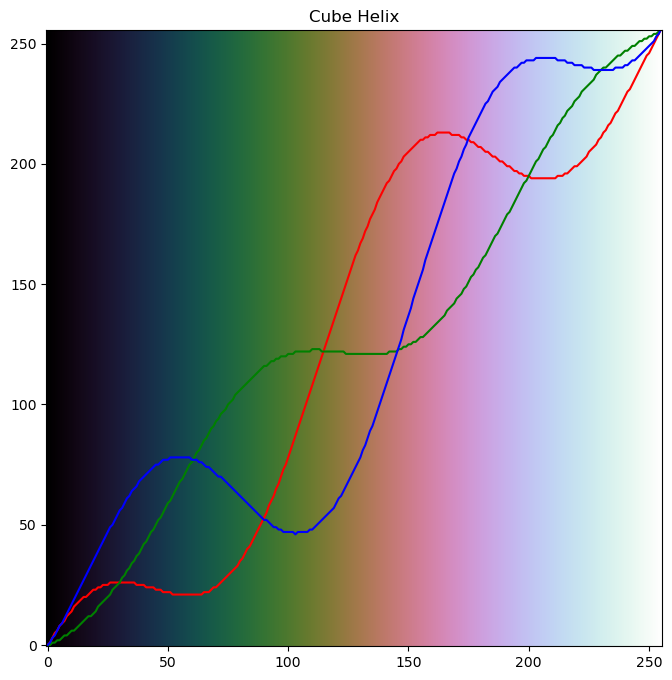

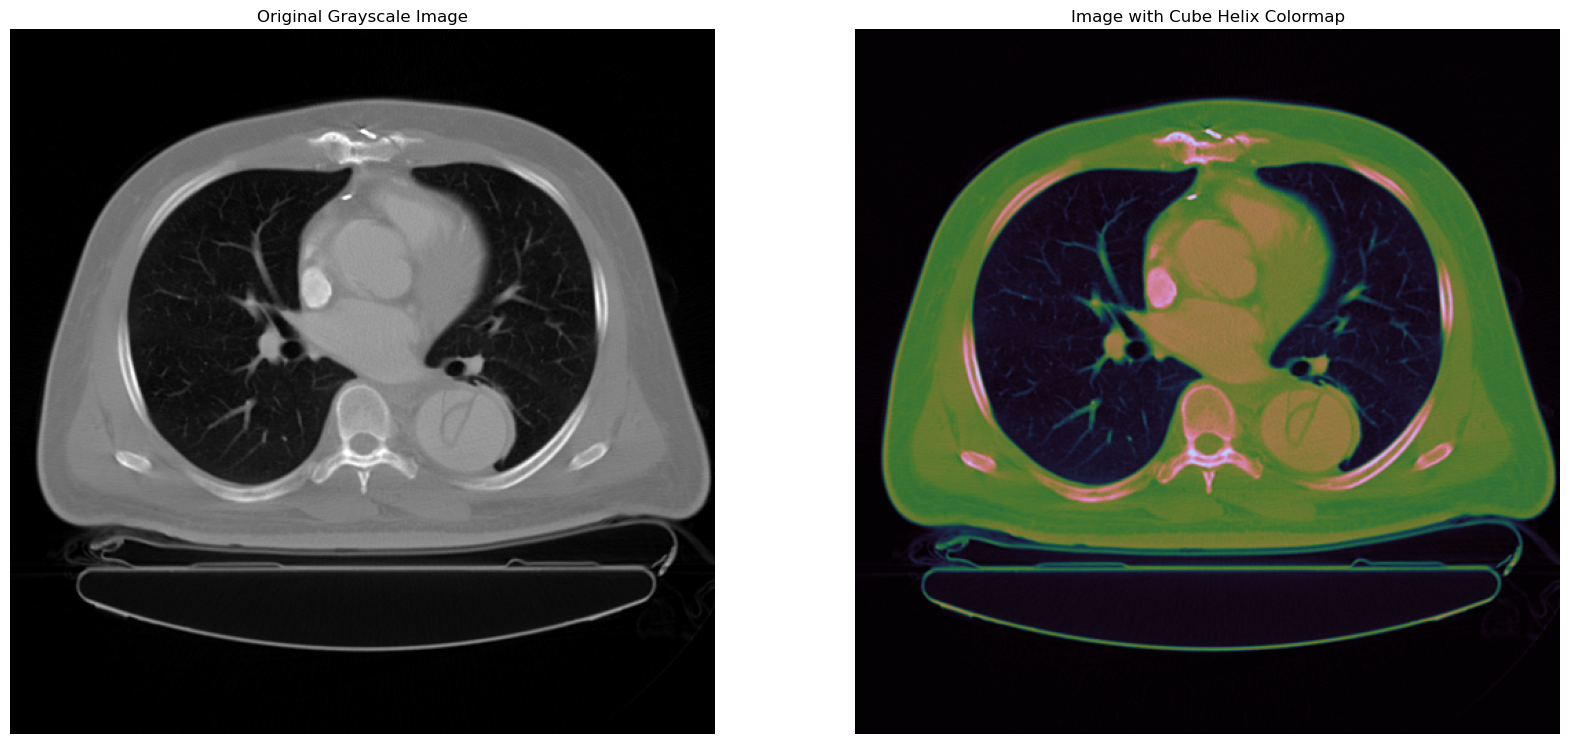

In [37]:
%matplotlib inline
import numpy as np
from imageio.v2 import imread
import matplotlib.pyplot as plt

start_color = 0.5
rotations = -1.5
hue = 1
gamma = 1
m = np.asmatrix([[-.14861, 1.78277],
            [-.29227, -.90649],
            [1.97294, 0]])

def generate_cube_helix_lookup_table():
    """Generate a lookup table for cube helix color mapping.
    
    Return: 
        lookup_table (ndarray): The cube helix color map. (256,3)
    """
    lookup_table = np.empty((256,3), float)
    
    for i in np.arange(256):
        g = i / 255.0
        lambda_gamma = g ** gamma
        phi = 2 * np.pi * (start_color / 3 + rotations * lambda_gamma)
        a = hue * lambda_gamma * (1 - lambda_gamma) / 2
        
        # YOUR CODE HERE
        # raise NotImplementedError()
        
        rgb = lambda_gamma + a * (m @ np.array([[np.cos(phi)], [np.sin(phi)]]))
        lookup_table[i] = rgb.flatten()
        
        
    return lookup_table


def apply_colormap(img, loookup_table):
    """Apply a colormap to an image
    
    Args:
        img (ndarray): The image (ndim=2).
        lookup_table (ndarray): The lookup table (shape=(256,3)).
        
    Return:
        color_img (ndarray): The color image resulting from application of the colormap.
    """
    color_img = loookup_table[img]
    color_img[color_img>1] = 1.
    color_img[color_img<0] = 0.
    return color_img

img = imread('images/lung.png', pilmode='L')
lookup_table = generate_cube_helix_lookup_table()
img2 = apply_colormap(img, lookup_table)

gray = np.arange(0,256)
a = np.tile(np.arange(256),(256,1))

int_table = (lookup_table*256).astype(int)
plt.figure(figsize=(8,8))
plt.plot(gray, int_table[gray,0], 'red')
plt.plot(gray, int_table[gray,1], 'green')
plt.plot(gray, int_table[gray,2], 'blue')
plt.imshow(np.stack([int_table[a,0],int_table[a,1],int_table[a,2]],axis=2)/256, origin='lower')
plt.title("Cube Helix")
plt.show()

#plt.figure(figsize=(20,10))
#plt.subplot(1,2,1); plt.imshow(img, cmap = 'gray'); plt.axis('off')
#plt.subplot(1,2,2); plt.imshow(img2); plt.axis('off')
#plt.show()

plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title("Original Grayscale Image")

plt.subplot(1, 2, 2)
plt.imshow(img2)
plt.axis('off')
plt.title("Image with Cube Helix Colormap")
plt.show()


### Jet Colormap [Bonus]

Explain why the Jet Colormap (used, for example, as standard colormap in matlab), is problematic compared to Cube Helix. Think of perceived luminance and black and white printing.

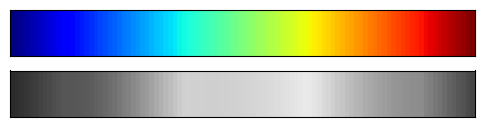

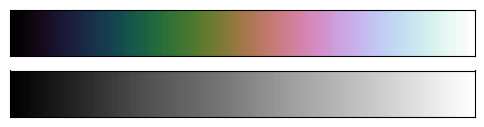

In [25]:
# This code was taken from 
# https://jakevdp.github.io/blog/2014/10/16/how-bad-is-your-colormap/

def grayify_cmap(cmap):
    """Return a grayscale version of the colormap
    
    Args:
        cmap (ndarray): RGB Colormap.
    
    Returns:
        (ndarray): Gray Colormap.
    
    """
    cmap = plt.get_cmap(cmap)
    colors = cmap(np.arange(cmap.N))
    
    # convert RGBA to perceived greyscale luminance
    # cf. http://alienryderflex.com/hsp.html
    RGB_weight = [0.299, 0.587, 0.114]
    luminance = np.sqrt(np.dot(colors[:, :3] ** 2, RGB_weight))
    colors[:, :3] = luminance[:, np.newaxis]
    
    return cmap.from_list(cmap.name + "_grayscale", colors, cmap.N)

def show_colormap(cmap):
    """Plots RGB colormap and grayified colormap
    
    Args: 
        cmap (ndarray): Colormap.
    
    """
    im = np.outer(np.ones(10), np.arange(100))
    fig, ax = plt.subplots(2, figsize=(6, 1.5),
                           subplot_kw=dict(xticks=[], yticks=[]))
    fig.subplots_adjust(hspace=0.1)
    ax[0].imshow(im, cmap=cmap)
    ax[1].imshow(im, cmap=grayify_cmap(cmap))
    
# printing the jet colormap and how it would look like if printed black and white
show_colormap('jet')

# doing the same for cube helix
show_colormap('cubehelix')

YOUR ANSWER HERE

The Jet colormap, commonly used in software like MATLAB, is problematic because it does not provide a smooth gradient in perceived luminance. This inconsistency can create artificial boundaries in the data, leading viewers to perceive features that aren’t actually there. Additionally, Jet performs poorly when printed in black and white, as its uneven luminance can cause colors of similar brightness to blend together in grayscale, making data distinctions unclear. In contrast, Cube Helix was designed with consistent luminance, allowing for accurate representation in both color and grayscale, making it a better choice for data visualization and black-and-white printing.